# Global Benchmark Analysis

This notebook performs comprehensive cross-benchmark analysis evaluating 4 key metrics across 3 benchmarks:
- **PubMedQA** (pubmedqa_new2): Baseline + Levels 1-6 (yes/no/maybe answers)
- **MedQA** (medqa): Baseline + Levels 1-6 (A/B/C/D answers)
- **MedMCQA** (medmcqa_2): Baseline + Levels 1-6 (A/B/C/D answers)

## Evaluation Points
1. Accuracy Under Structured Constraints**: How do structured constraints affect accuracy?
2. Output Validity and Schema Compliance**: How well do models follow structured schemas?
3. Chain of thought order: Does changing the schema's order (answer vs reasoning first) affect performance?
4. Confidence and Calibration Behavior**: Are models well-calibrated? Does structure affect calibration?
5. Decision Distribution Shifts**: Do structured constraints change answer patterns?


In [1]:
# Import libraries
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Import analysis utilities
from analysis_utils import (
    load_all_benchmark_data,
    parse_all_samples,
    compute_accuracy_metrics,
    compute_compliance_metrics,
    compute_calibration_metrics,
    compute_distribution_metrics,
    compute_statistical_significance,
    compare_l3_vs_l3_inverted,
    compute_shift_patterns,
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Define paths for all 3 benchmarks
BASE_DIR = Path.cwd()

# Create plots directory
PLOTS_DIR = BASE_DIR / "global_analysis" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(" Imports and paths configured")


 Imports and paths configured


## 1. Data Loading & Parsing


In [ ]:
all_results, all_samples = load_all_benchmark_data(BASE_DIR)


Loading PubMedQA...
   baseline: pubmedqa_baseline_2025-12-02T17-10-15.514633.json
   L1: pubmedqa_level1_2025-12-08T14-28-16.793274.json
   L2: pubmedqa_level2_2025-12-08T14-33-38.031833.json
   L3: pubmedqa_level3_2025-12-08T16-37-05.472225.json
   L3_inverted: pubmedqa_level3_inverted_2025-12-12T13-14-54.900999.json
   L4: pubmedqa_level4_2025-12-08T17-53-41.436382.json
   L5: pubmedqa_level5_2025-12-08T19-23-52.009458.json
   L6: pubmedqa_level6_2025-12-08T19-45-46.527366.json
   baseline samples: 500 samples
   L1 samples: 500 samples
   L2 samples: 500 samples
   L3 samples: 500 samples
   L3_inverted samples: 500 samples
   L4 samples: 500 samples
   L5 samples: 500 samples
   L6 samples: 500 samples
Loading MedQA...
   baseline: medqa4option_BASELINE.json
   L1: medqa4options_LEVEL1.json
   L2: medqa4options_LEVEL2.json
   L3: medqa4options_LEVEL3.json
   L3_inverted: medqa_inverted_cot_2025-12-12T15-31-19.422661.json
   L4: medqa4options_LEVEL4.json
   L5: medqa4options_LEVEL5

In [ ]:
# Parse all samples
all_parsed = parse_all_samples(all_samples)


✓ Parsed pubmedqa baseline: 500 samples
✓ Parsed pubmedqa L1: 500 samples
✓ Parsed pubmedqa L2: 500 samples
✓ Parsed pubmedqa L3: 500 samples
✓ Parsed pubmedqa L3_inverted: 500 samples
✓ Parsed pubmedqa L4: 500 samples
✓ Parsed pubmedqa L5: 500 samples
✓ Parsed pubmedqa L6: 500 samples
✓ Parsed medqa baseline: 1273 samples
✓ Parsed medqa L1: 1273 samples
✓ Parsed medqa L2: 1273 samples
✓ Parsed medqa L3: 1273 samples
✓ Parsed medqa L3_inverted: 1273 samples
✓ Parsed medqa L4: 1273 samples
✓ Parsed medqa L5: 1273 samples
✓ Parsed medqa L6: 1273 samples
✓ Parsed medmcqa baseline: 4183 samples
✓ Parsed medmcqa L1: 4183 samples
✓ Parsed medmcqa L2: 4183 samples
✓ Parsed medmcqa L3: 4183 samples
✓ Parsed medmcqa L3_inverted: 4183 samples
✓ Parsed medmcqa L4: 4183 samples
✓ Parsed medmcqa L5: 4183 samples
✓ Parsed medmcqa L6: 4183 samples

 All samples parsed


## 4.1 Accuracy Under Structured Constraints

This section analyzes how structured constraints affect model accuracy across different benchmarks and schema levels.


In [ ]:
# Extract accuracy metrics 
accuracy_df = compute_accuracy_metrics(all_results, all_parsed)
print("Accuracy data extracted:")
print(accuracy_df.groupby('benchmark')['level'].count())


Accuracy data extracted:
benchmark
medmcqa     8
medqa       8
pubmedqa    8
Name: level, dtype: int64


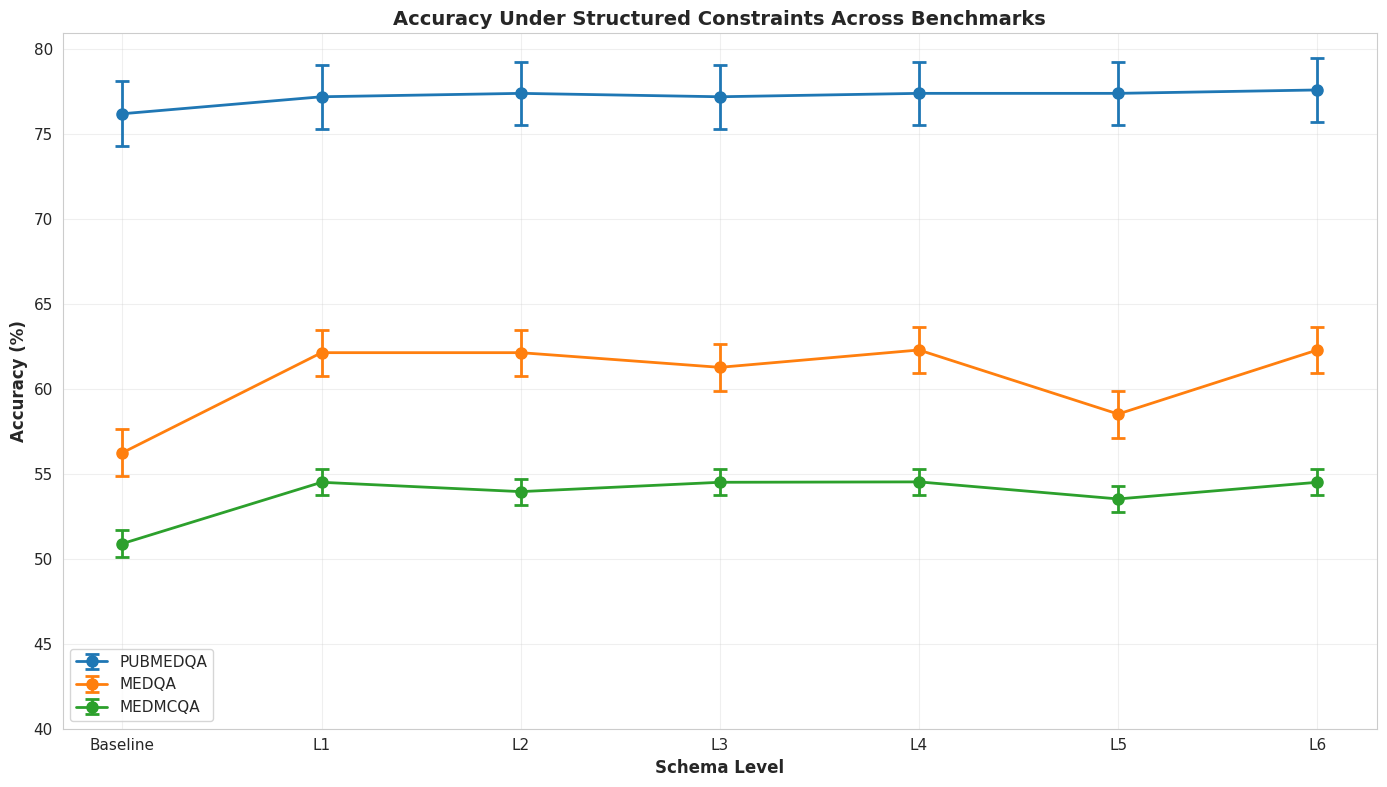

In [5]:
# Create accuracy comparison visualizations

#  Multi-benchmark accuracy comparison (line plot with error bars)
fig, ax = plt.subplots(figsize=(14, 8))

# Define level order
level_order = ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
level_labels = ['Baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    # Filter to available levels and sort
    bench_data = bench_data[bench_data['level'].isin(level_order)]
    bench_data['level_num'] = bench_data['level'].map({l: i for i, l in enumerate(level_order) if l in bench_data['level'].values})
    bench_data = bench_data.sort_values('level_num')
    
    x_pos = bench_data['level_num'].values
    y_vals = bench_data['accuracy'].values * 100
    y_err = bench_data['accuracy_stderr'].values * 100
    
    ax.errorbar(x_pos, y_vals, yerr=y_err, marker='o', linewidth=2, 
                markersize=8, label=benchmark.upper(), capsize=5, capthick=2)

ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Under Structured Constraints Across Benchmarks', fontsize=14, fontweight='bold')
ax.set_xticks(range(len([l for l in level_order if l in accuracy_df['level'].values])))
ax.set_xticklabels([l for l in level_labels if l.replace('Baseline', 'baseline') in accuracy_df['level'].values])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=40)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


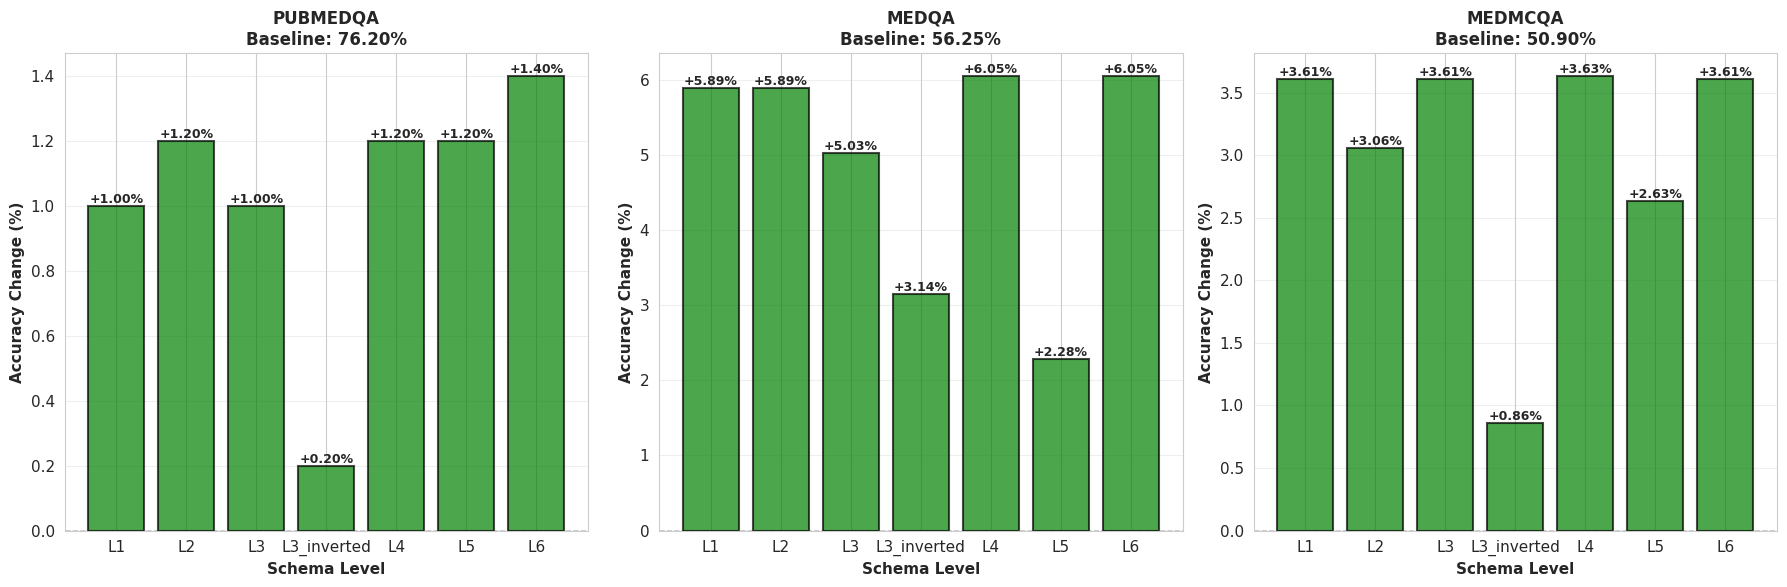

In [6]:
# Accuracy change from baseline (bar chart)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
benchmarks = ['pubmedqa', 'medqa', 'medmcqa']

for idx, benchmark in enumerate(benchmarks):
    ax = axes[idx]
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    
    # Get baseline accuracy
    baseline_data = bench_data[bench_data['level'] == 'baseline']
    if len(baseline_data) > 0:
        baseline_acc = baseline_data['accuracy'].values[0] * 100
    else:
        # For pubmedqa, use L1 as reference
        baseline_acc = bench_data[bench_data['level'] == 'L1']['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == 'L1']) > 0 else 0
    
    # Calculate change from baseline
    bench_data = bench_data[bench_data['level'] != 'baseline']
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    changes = (bench_data['accuracy'].values * 100) - baseline_acc
    
    colors = ['green' if c > 0 else 'red' for c in changes]
    bars = ax.bar(levels, changes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy Change (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nBaseline: {baseline_acc:.2f}%', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, change in zip(bars, changes):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{change:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_change_from_baseline.png', dpi=300, bbox_inches='tight')
plt.show()


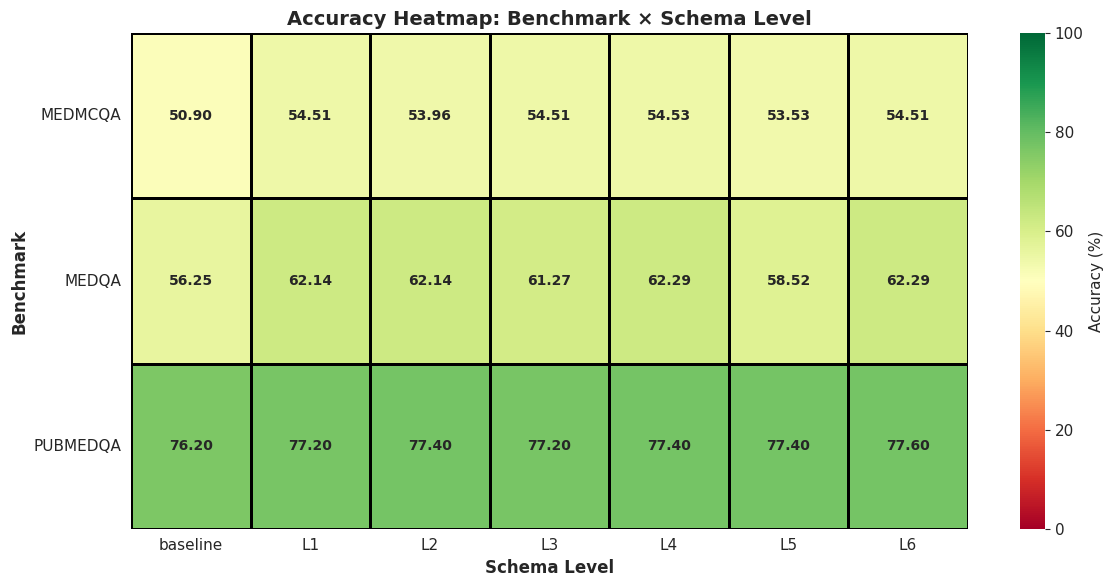

In [7]:
# Heatmap showing accuracy by benchmark and level
pivot_data = accuracy_df.pivot(index='benchmark', columns='level', values='accuracy') * 100

# Reorder columns
level_order_available = [l for l in level_order if l in pivot_data.columns]
pivot_data = pivot_data[level_order_available]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Accuracy (%)'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Heatmap: Benchmark × Schema Level', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in pivot_data.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Statistical significance tests between levels
compute_statistical_significance(accuracy_df, all_parsed)


STATISTICAL SIGNIFICANCE TESTS: Accuracy Differences Between Levels

PUBMEDQA:
  baseline vs L1: Δ = +1.00%, p = 0.4463 
  baseline vs L2: Δ = +1.20%, p = 0.3769 
  baseline vs L3: Δ = +1.00%, p = 0.4463 
  baseline vs L3_inverted: Δ = +0.20%, p = 0.8966 
  baseline vs L4: Δ = +1.20%, p = 0.3769 
  baseline vs L5: Δ = +1.20%, p = 0.3662 
  baseline vs L6: Δ = +1.40%, p = 0.2972 

MEDQA:
  baseline vs L1: Δ = +5.89%, p = 0.0000 ***
  baseline vs L2: Δ = +5.89%, p = 0.0000 ***
  baseline vs L3: Δ = +5.03%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +3.14%, p = 0.0281 *
  baseline vs L4: Δ = +6.05%, p = 0.0000 ***
  baseline vs L5: Δ = +2.28%, p = 0.0596 
  baseline vs L6: Δ = +6.05%, p = 0.0000 ***

MEDMCQA:
  baseline vs L1: Δ = +3.61%, p = 0.0000 ***
  baseline vs L2: Δ = +3.06%, p = 0.0000 ***
  baseline vs L3: Δ = +3.61%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +0.86%, p = 0.2860 
  baseline vs L4: Δ = +3.63%, p = 0.0000 ***
  baseline vs L5: Δ = +2.63%, p = 0.0002 ***
  bas

## 4.2 Output Validity and Schema Compliance

This section analyzes how well models follow structured schemas, including:
1. **JSON Validity Rates (Parseable Answer Rates)**: For baseline, this measures the rate of parseable answers extracted from text. For schema levels, this measures the rate of valid JSON that can be parsed.
2. **Conditional Schema Compliance**: Among samples with valid JSON, the percentage that are schema-compliant.
3. **Compliance Breakdown**: Stacked visualization showing Valid JSON + Compliant, Valid JSON + Non-Compliant, and Invalid JSON categories across all levels.


In [ ]:
# Compute compliance metrics
compliance_df = compute_compliance_metrics(all_parsed)
print("Compliance metrics computed")
print(compliance_df.groupby('benchmark')[['json_valid_rate', 'schema_compliant_rate']].mean())


Compliance metrics computed
           json_valid_rate  schema_compliant_rate
benchmark                                        
medmcqa           0.775341               0.884921
medqa             0.763060               0.855165
pubmedqa          0.834250               0.958500


In [10]:
# Display JSON validity rates (parseable answer rates) and conditional schema compliance
print("="*100)
print("JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE")
print("="*100)
print("\nFor baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)")
print("For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)")
print("Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON\n")

# Create summary table
summary_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        parseable_rate = row['parseable_answer_rate'] * 100
        json_valid_rate = row['json_valid_rate'] * 100
        schema_compliant_rate = row['schema_compliant_rate'] * 100
        
        # Conditional compliance (only for schema levels)
        if level != 'baseline' and not pd.isna(row['schema_compliant_rate_given_valid_json']):
            conditional_compliance = row['schema_compliant_rate_given_valid_json'] * 100
            conditional_str = f"{conditional_compliance:.2f}%"
        else:
            conditional_str = "N/A"
        
        summary_data.append({
            'Benchmark': benchmark.upper(),
            'Level': level,
            'Parseable Answer Rate (%)': f"{parseable_rate:.2f}",
            'JSON Valid Rate (%)': f"{json_valid_rate:.2f}",
            'Schema Compliant Rate (%)': f"{schema_compliant_rate:.2f}",
            'Schema Compliant (within Valid JSON) (%)': conditional_str
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*100)


JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE

For baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)
For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)
Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON

Benchmark       Level Parseable Answer Rate (%) JSON Valid Rate (%) Schema Compliant Rate (%) Schema Compliant (within Valid JSON) (%)
 PUBMEDQA          L1                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L2                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L3                     97.60               97.60                     97.60                                  100.00%
 PUBMEDQA L3_inverted                     95.80               95.80                     95.80            

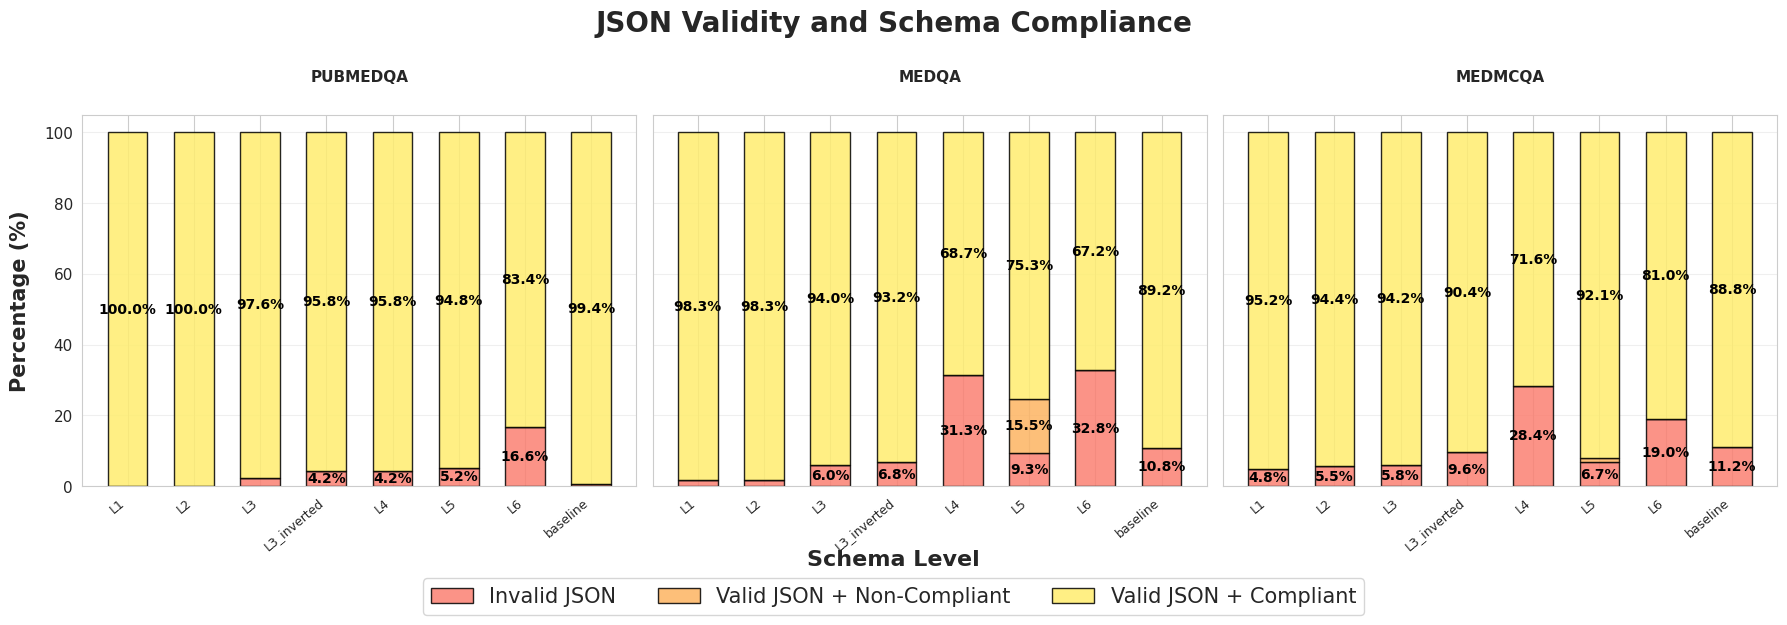

In [11]:
import matplotlib as mpl
# Stacked bar chart: Valid JSON + Compliant, Valid JSON + Non-Compliant, Invalid JSON
# Create subplots with shared axes - increase height to accommodate all elements
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Single title for all subplots - vertically centered above subplots
fig.suptitle('JSON Validity and Schema Compliance', fontsize=20, fontweight='bold', y=0.9)

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    # Get rates as percentages
    rate_invalid_json = bench_data['rate_invalid_json'].values * 100
    rate_valid_json_non_compliant = bench_data['rate_valid_json_non_compliant'].values * 100
    rate_valid_json_compliant = bench_data['rate_valid_json_compliant'].values * 100
    
    x = np.arange(len(levels))
    width = 0.6
    cmap = mpl.colormaps["Set3"]
    c_invalid, c_noncomp, c_comp = cmap([0.3, 0.45, 1.5])

    bars1 = ax.bar(x, rate_invalid_json, width, label='Invalid JSON',
                color=c_invalid, alpha=0.85, edgecolor='black', linewidth=1)

    bars2 = ax.bar(x, rate_valid_json_non_compliant, width, bottom=rate_invalid_json,
                label='Valid JSON + Non-Compliant',
                color=c_noncomp, alpha=0.85, edgecolor='black', linewidth=1)

    bars3 = ax.bar(x, rate_valid_json_compliant, width,
                bottom=rate_invalid_json + rate_valid_json_non_compliant,
                label='Valid JSON + Compliant',
                color=c_comp, alpha=0.85, edgecolor='black', linewidth=1)

    # Only show y-axis label on left subplot (first one)
    if idx == 0:
        ax.set_ylabel('Percentage (%)', fontsize=15, fontweight='bold', labelpad=10)
    
    # Add benchmark label as subtitle - position in the top margin, well above plot area
    ax.text(0.5, 1.08, benchmark.upper(), transform=ax.transAxes, 
            fontsize=11, fontweight='bold', ha='center', va='bottom')
    
    ax.set_xticks(x)
    # Improve x-axis label readability - reduce rotation slightly and adjust alignment
    ax.set_xticklabels(levels, rotation=40, ha='right', fontsize=9)
    
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)
    
    # Add value labels on segments (only if segment is large enough to be visible)
    for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
        # Invalid JSON label
        h1 = bar1.get_height()
        if h1 > 3:  # Only label if segment is > 3%
            ax.text(bar1.get_x() + bar1.get_width()/2., h1/2,
                    f'{h1:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        
        # Valid JSON + Non-Compliant label
        h2 = bar2.get_height()
        bottom2 = bar2.get_y()
        if h2 > 3:  # Only label if segment is > 3%
            ax.text(bar2.get_x() + bar2.get_width()/2., bottom2 + h2/2,
                    f'{h2:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        
        # Valid JSON + Compliant label
        h3 = bar3.get_height()
        bottom3 = bar3.get_y()
        if h3 > 3:  # Only label if segment is > 3%
            ax.text(bar3.get_x() + bar3.get_width()/2., bottom3 + h3/2,
                    f'{h3:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='black')

# Create shared legend at the bottom center of the figure (below x-axis label)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=15, frameon=True, 
           bbox_to_anchor=(0.5, 0.02))

# Add centered x-axis label above legend
fig.text(0.5, 0.1, 'Schema Level', fontsize=16, fontweight='bold', ha='center', va='bottom')

# Adjust layout to accommodate shared title, benchmark labels, and legend
plt.tight_layout(rect=[0, 0.1, 1, 0.92])
plt.savefig(PLOTS_DIR / 'json_validity_compliance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.3  L3 vs L3_inverted: Schema Order Impact Analysis

**Key Difference**: 
- **L3**: Answer first, then reasoning/justification (standard CoT)
- **L3_inverted**: Reasoning/justification first, then answer (inverted CoT)

**Hypothesis**: Requiring reasoning before the answer (inverted CoT) forces models to think through problems before committing, potentially improving accuracy and reasoning quality.

This section compares these two approaches across all benchmarks.


In [ ]:
# L3 vs L3_inverted Comparison Analysis 
l3_comparison_df = compare_l3_vs_l3_inverted(compliance_df, accuracy_df, all_parsed)
print("L3 vs L3_inverted Comparison Data:")
print(l3_comparison_df[['benchmark', 'l3_accuracy', 'l3_inv_accuracy', 'accuracy_diff', 
                        'l3_json_valid', 'l3_inv_json_valid', 'l3_schema_compliant', 'l3_inv_schema_compliant']].to_string(index=False))


L3 vs L3_inverted Comparison Data:
benchmark  l3_accuracy  l3_inv_accuracy  accuracy_diff  l3_json_valid  l3_inv_json_valid  l3_schema_compliant  l3_inv_schema_compliant
 pubmedqa    77.200000        76.400000      -0.800000      97.600000          95.800000            97.600000                95.800000
    medqa    61.272584        59.387274      -1.885310      94.029851          93.244305            94.029851                93.244305
  medmcqa    54.506335        51.757112      -2.749223      94.166866          90.437485            94.166866                90.437485


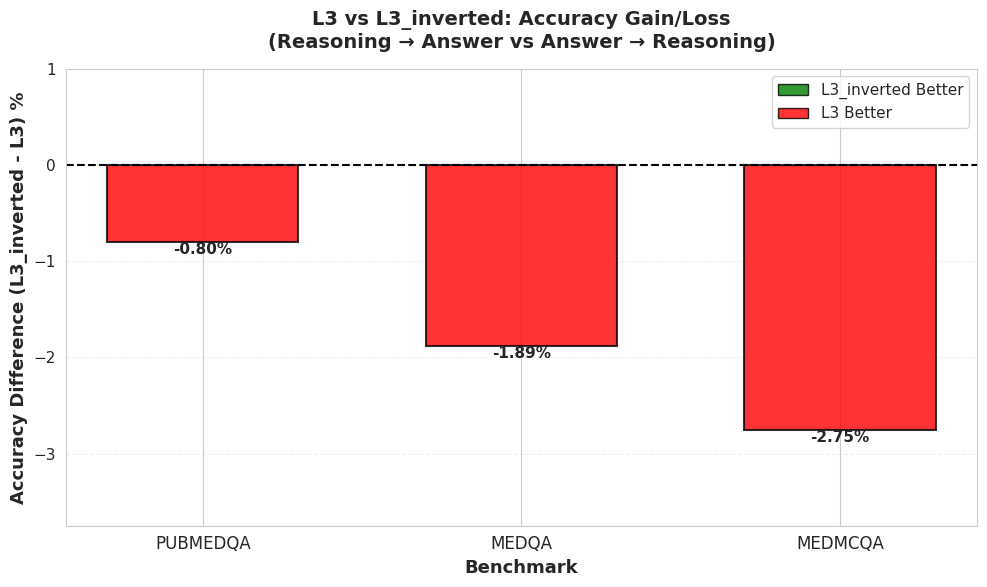


L3 vs L3_inverted: Summary Statistics

Metric                         L3              L3_inverted     Difference     
--------------------------------------------------------------------------------

PUBMEDQA:
  Accuracy (%)              77.20           76.40           -0.80%
  JSON Valid (%)            97.60           95.80           -1.80%
  Schema Compliant (%)      97.60           95.80           -1.80%
  Avg Reasoning Length      198             179             -19 chars

MEDQA:
  Accuracy (%)              61.27           59.39           -1.89%
  JSON Valid (%)            94.03           93.24           -0.79%
  Schema Compliant (%)      94.03           93.24           -0.79%
  Avg Reasoning Length      200             200             +0 chars

MEDMCQA:
  Accuracy (%)              54.51           51.76           -2.75%
  JSON Valid (%)            94.17           90.44           -3.73%
  Schema Compliant (%)      94.17           90.44           -3.73%
  Avg Reasoning Length      1

In [13]:
# Create L3 vs L3_inverted accuracy gain/loss visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(l3_comparison_df))
colors = ['green' if d > 0 else 'red' for d in l3_comparison_df['accuracy_diff']]
bars = ax.bar(x, l3_comparison_df['accuracy_diff'], 
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add zero reference line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

# Add value labels on bars
for bar, diff in zip(bars, l3_comparison_df['accuracy_diff']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{diff:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Difference (L3_inverted - L3) %', fontsize=13, fontweight='bold')
ax.set_title('L3 vs L3_inverted: Accuracy Gain/Loss\n(Reasoning → Answer vs Answer → Reasoning)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in l3_comparison_df['benchmark']], fontsize=12)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim(bottom=min(l3_comparison_df['accuracy_diff'].min() - 1, -1) if len(l3_comparison_df) > 0 else -1,
            top=max(l3_comparison_df['accuracy_diff'].max() + 1, 1) if len(l3_comparison_df) > 0 else 1)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.8, edgecolor='black', label='L3_inverted Better'),
    Patch(facecolor='red', alpha=0.8, edgecolor='black', label='L3 Better')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'l3_vs_l3_inverted_accuracy_gain_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("L3 vs L3_inverted: Summary Statistics")
print("="*80)
print(f"\n{'Metric':<30} {'L3':<15} {'L3_inverted':<15} {'Difference':<15}")
print("-"*80)
for _, row in l3_comparison_df.iterrows():
    benchmark = row['benchmark'].upper()
    print(f"\n{benchmark}:")
    print(f"  Accuracy (%)              {row['l3_accuracy']:<15.2f} {row['l3_inv_accuracy']:<15.2f} {row['accuracy_diff']:+.2f}%")
    print(f"  JSON Valid (%)            {row['l3_json_valid']:<15.2f} {row['l3_inv_json_valid']:<15.2f} {row['json_valid_diff']:+.2f}%")
    print(f"  Schema Compliant (%)      {row['l3_schema_compliant']:<15.2f} {row['l3_inv_schema_compliant']:<15.2f} {row['schema_compliant_diff']:+.2f}%")
    print(f"  Avg Reasoning Length      {row['l3_avg_reasoning_length']:<15.0f} {row['l3_inv_avg_reasoning_length']:<15.0f} {row['reasoning_length_diff']:+.0f} chars")

print("\n" + "="*80)
print("Key Findings:")
print("="*80)
for _, row in l3_comparison_df.iterrows():
    benchmark = row['benchmark'].upper()
    acc_diff = row['accuracy_diff']
    if acc_diff > 0:
        print(f"✓ {benchmark}: L3_inverted improves accuracy by {acc_diff:.2f}%")
    elif acc_diff < 0:
        print(f"✗ {benchmark}: L3_inverted decreases accuracy by {abs(acc_diff):.2f}%")
    else:
        print(f"= {benchmark}: No accuracy difference")
print("="*80)


## 4.4 Confidence and Calibration Behavior

This section analyzes model calibration: how well confidence scores correlate with actual accuracy, and whether structured constraints affect calibration.


In [ ]:
# Extract confidence and correctness data 
calibration_data = compute_calibration_metrics(all_parsed)
calibration_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['confidences', 'correct']} 
                                for d in calibration_data])
print("Calibration metrics computed")
print(calibration_df.groupby('benchmark')[['ece', 'correlation']].mean())


Calibration metrics computed
                ece  correlation
benchmark                       
medmcqa    0.303002     0.031356
medqa      0.286796     0.009947
pubmedqa   0.196713     0.088443


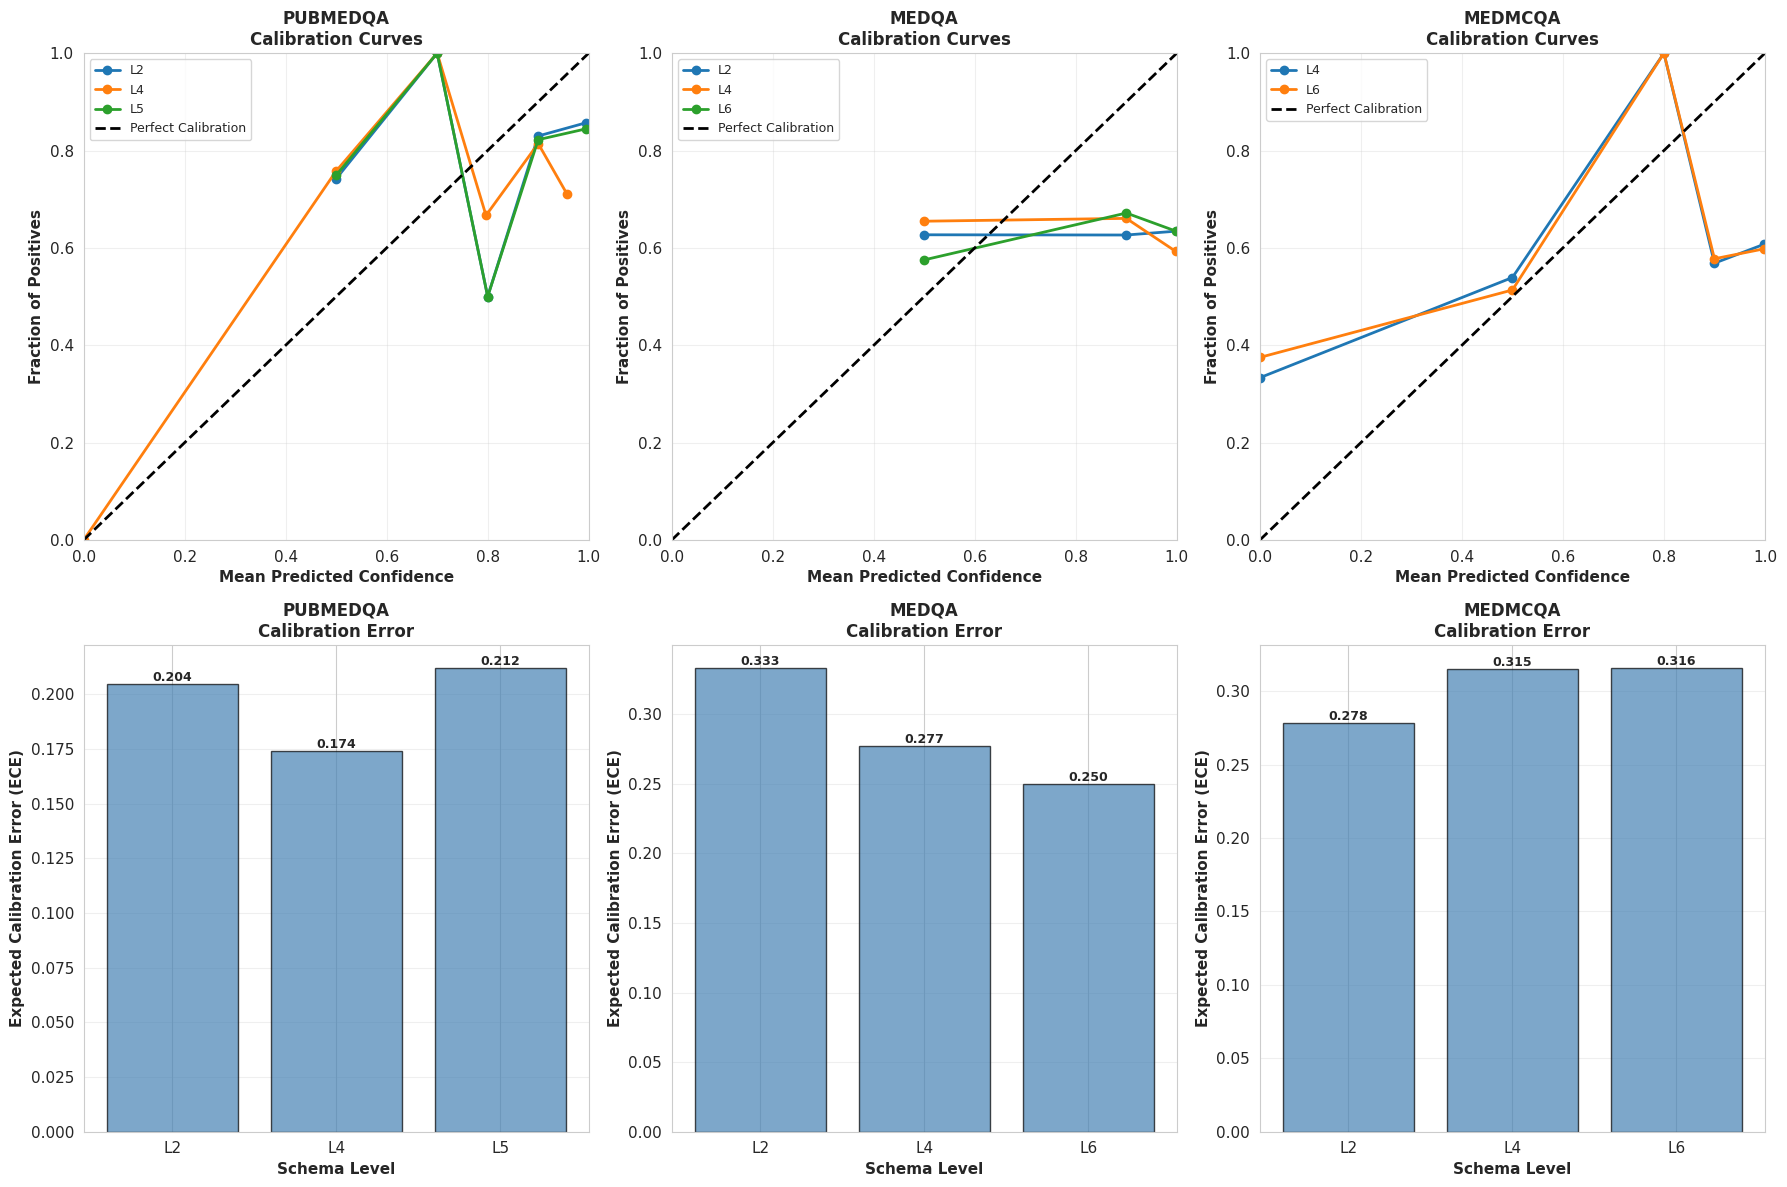

In [15]:
# Calibration curves for each benchmark/level
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax1 = axes[0, idx]
    ax2 = axes[1, idx]
    
    for calib_item in calibration_data:
        if calib_item['benchmark'] == benchmark:
            level = calib_item['level']
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            
            if len(confidences) > 10:  # Need enough samples
                try:
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        correct, confidences, n_bins=10, strategy='uniform'
                    )
                    ax1.plot(mean_predicted_value, fraction_of_positives, marker='o', 
                            label=level, linewidth=2, markersize=6)
                except:
                    pass
    
    # Perfect calibration line
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.set_xlabel('Mean Predicted Confidence', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
    ax1.set_title(f'{benchmark.upper()}\nCalibration Curves', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # ECE comparison
    bench_calib = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_calib = bench_calib.sort_values('level')
    
    if len(bench_calib) > 0:
        ax2.bar(bench_calib['level'], bench_calib['ece'], alpha=0.7, color='steelblue', edgecolor='black')
        ax2.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Expected Calibration Error (ECE)', fontsize=11, fontweight='bold')
        ax2.set_title(f'{benchmark.upper()}\nCalibration Error', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, (level, ece) in enumerate(zip(bench_calib['level'], bench_calib['ece'])):
            ax2.text(i, ece, f'{ece:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()


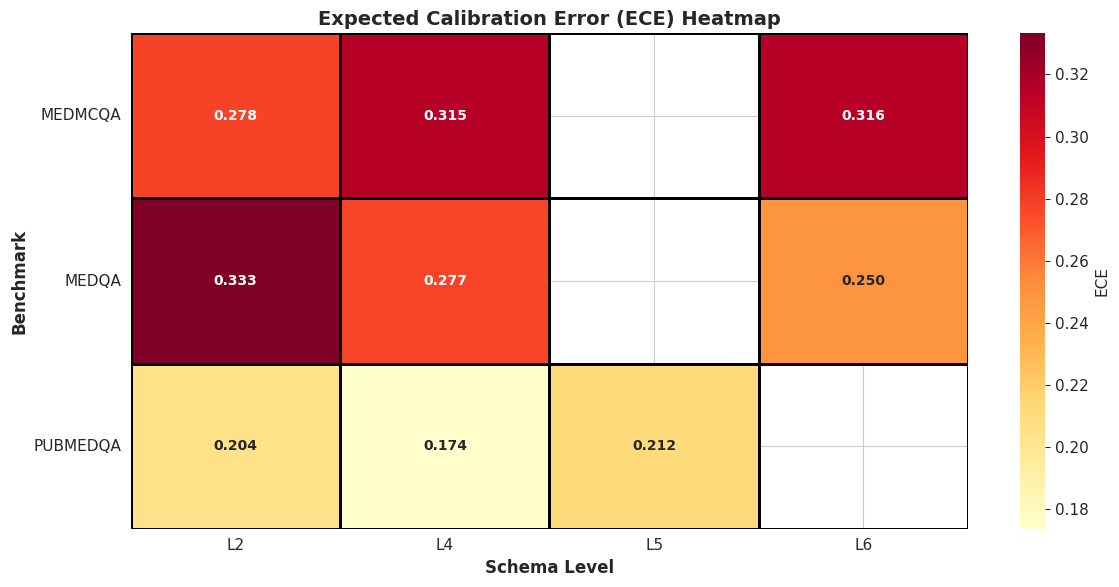

In [16]:
# ECE comparison across levels (heatmap)
ece_pivot = calibration_df.pivot(index='benchmark', columns='level', values='ece')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ece_pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'ECE'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Expected Calibration Error (ECE) Heatmap', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in ece_pivot.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ece_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.5 Comprehensive Answer Distribution Shift Analysis

This section provides a comprehensive multi-metric analysis of answer distribution shifts across all schema levels and benchmarks, using multiple statistical approaches to identify patterns and relationships between distribution changes and performance metrics.


In [ ]:
# Comprehensive Distribution Shift Analysis 
comprehensive_distribution_data, comprehensive_dist_df = compute_distribution_metrics(all_parsed)

print("Comprehensive distribution metrics computed:")
print(f"  Total (benchmark, level) combinations: {len(comprehensive_dist_df)}")
print(f"  Metrics: KL Divergence, Jensen-Shannon, Total Variation, Wasserstein, Chi-square")


Comprehensive distribution metrics computed:
  Total (benchmark, level) combinations: 24
  Metrics: KL Divergence, Jensen-Shannon, Total Variation, Wasserstein, Chi-square


In [ ]:
# Step 2: Analyze shift patterns - direction and magnitude 
shift_patterns_df = compute_shift_patterns(comprehensive_distribution_data, all_parsed)
print("Shift patterns analyzed:")
print(f"  Total level transitions: {len(shift_patterns_df)}")


Shift patterns analyzed:
  Total level transitions: 21


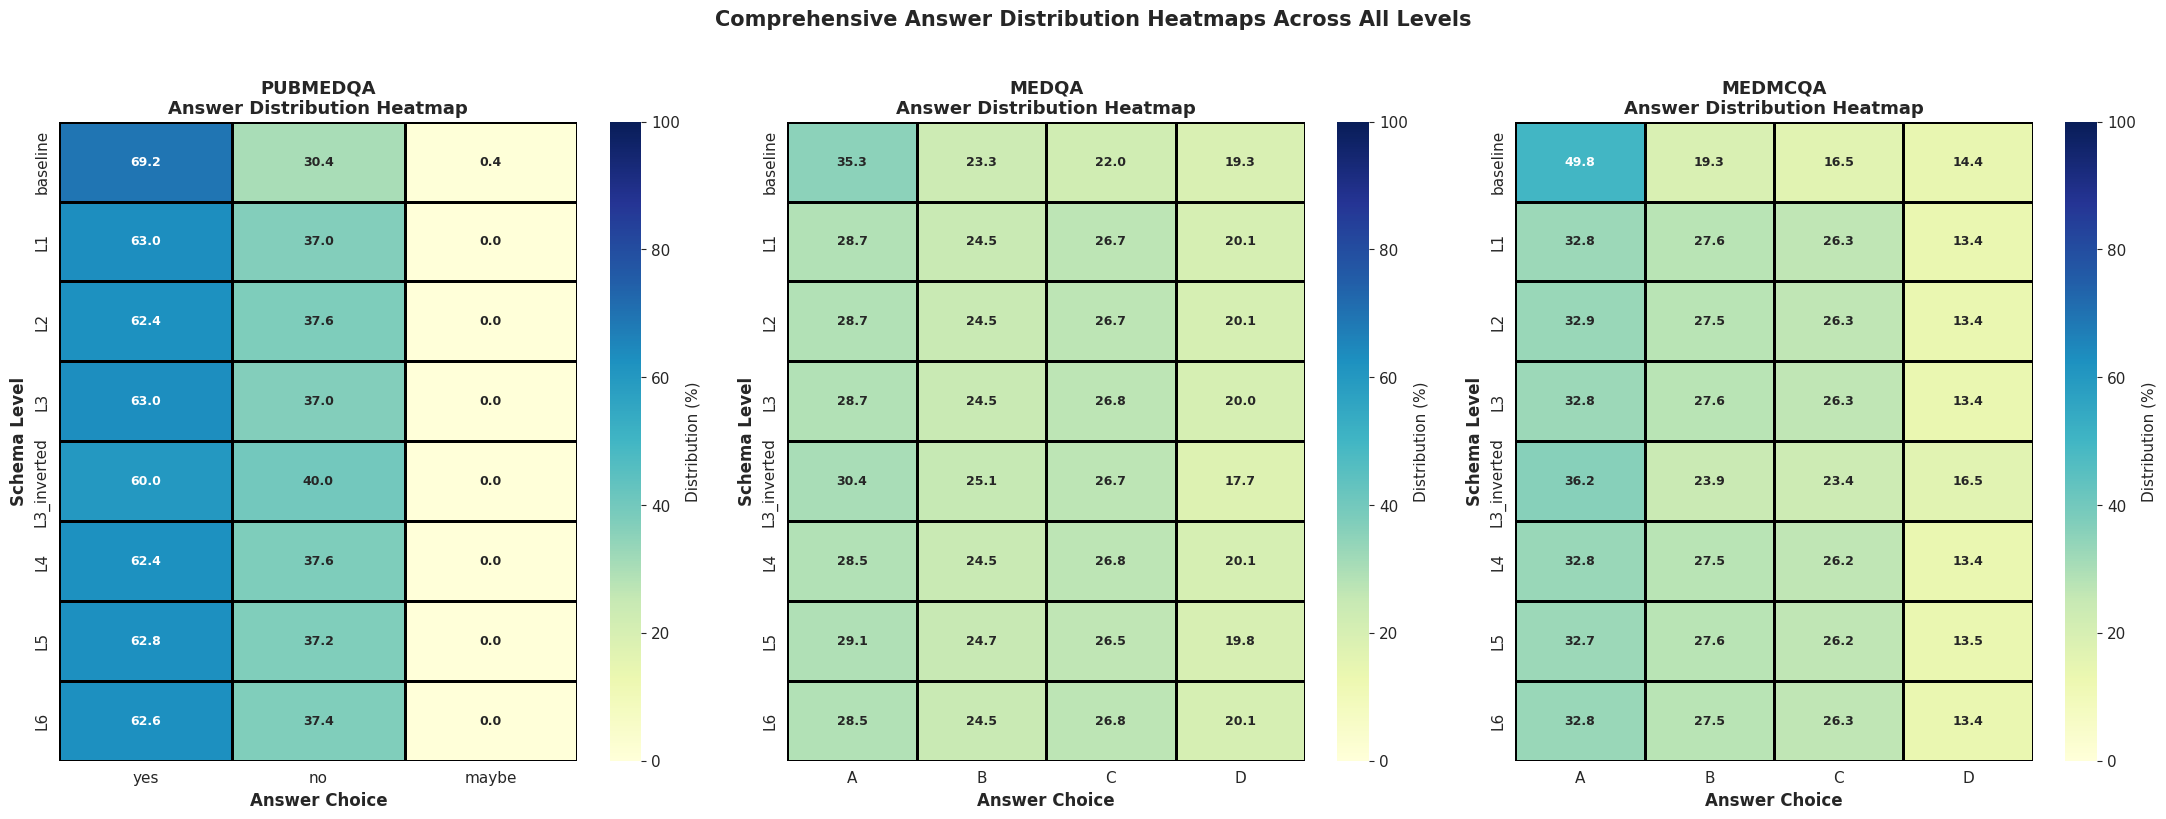

In [19]:
# Create comprehensive heatmaps showing distributions across all (benchmark × level × answer_choice)

# Create a unified heatmap showing all distributions
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_dist = [d for d in comprehensive_distribution_data if d['benchmark'] == benchmark]
    
    if not bench_dist:
        continue
    
    valid_answers = bench_dist[0]['valid_answers']
    # Sort levels: baseline first, then L1-L6, then L3_inverted
    level_order = ['baseline', 'L1', 'L2', 'L3', 'L3_inverted', 'L4', 'L5', 'L6']
    levels = [l for l in level_order if any(d['level'] == l for d in bench_dist)]
    
    # Create matrix
    dist_matrix = []
    for level in levels:
        dist_item = next((d for d in bench_dist if d['level'] == level), None)
        if dist_item:
            dist = [dist_item['distribution'].get(a, 0) for a in valid_answers]
            dist_matrix.append(dist)
        else:
            dist_matrix.append([0] * len(valid_answers))
    
    dist_matrix = np.array(dist_matrix)
    
    sns.heatmap(dist_matrix, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=levels,
                cbar_kws={'label': 'Distribution (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    ax.set_xlabel('Answer Choice', fontsize=12, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=12, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Distribution Heatmap', fontsize=13, fontweight='bold')

plt.suptitle('Comprehensive Answer Distribution Heatmaps Across All Levels', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comprehensive_distribution_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


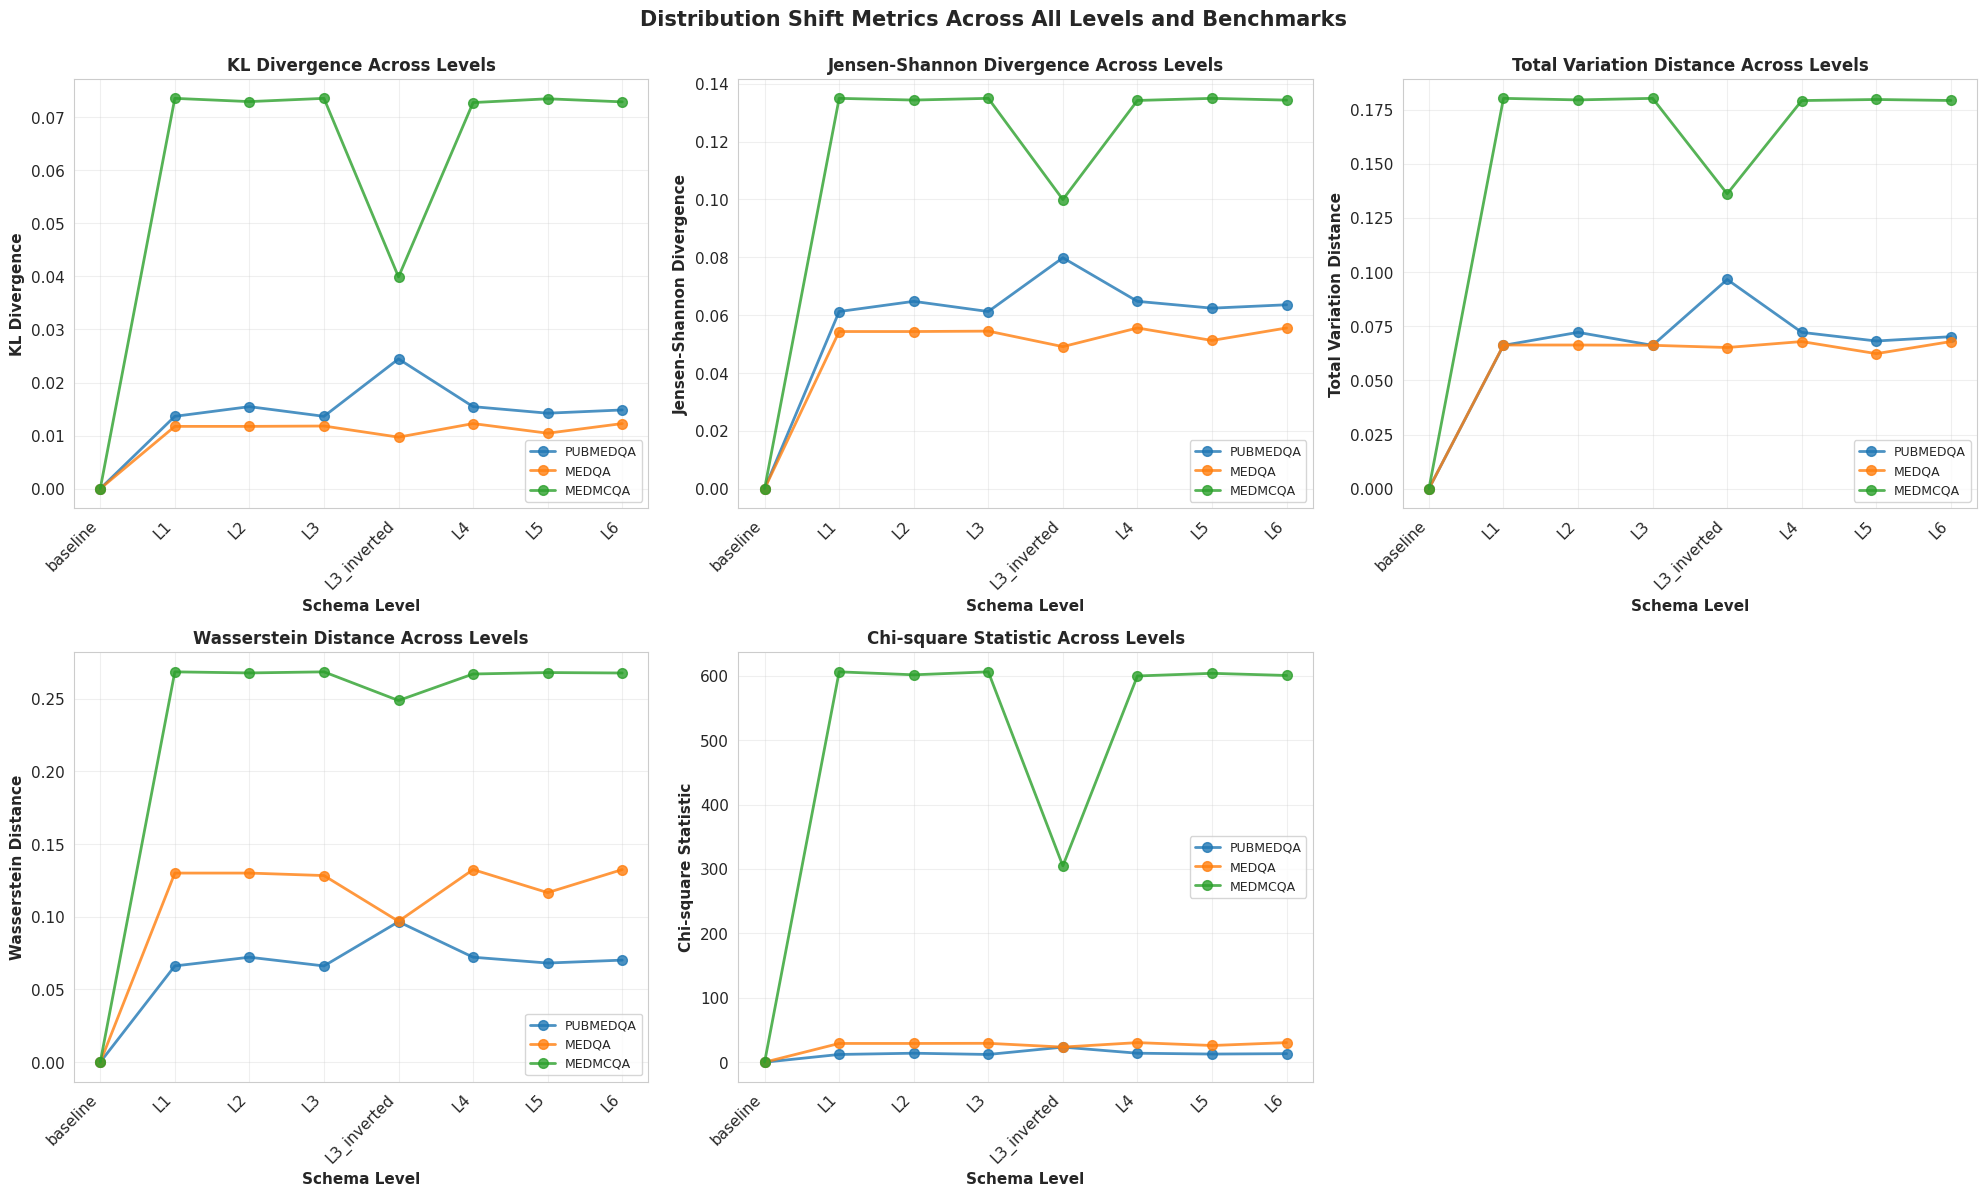

In [20]:
#distribution shift metrics across levels

# Define level order for consistent plotting
level_order = ['baseline', 'L1', 'L2', 'L3', 'L3_inverted', 'L4', 'L5', 'L6']

# Create multi-panel figure showing all metrics
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

metrics_to_plot = [
    ('kl_divergence', 'KL Divergence', 'steelblue'),
    ('jensen_shannon', 'Jensen-Shannon Divergence', 'darkgreen'),
    ('total_variation', 'Total Variation Distance', 'coral'),
    ('wasserstein', 'Wasserstein Distance', 'purple'),
    ('chi2_statistic', 'Chi-square Statistic', 'darkred'),
]

for metric_idx, (metric_col, metric_name, color) in enumerate(metrics_to_plot):
    row = metric_idx // 3
    col = metric_idx % 3
    ax = axes[row, col]
    
    for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
        bench_data = comprehensive_dist_df[comprehensive_dist_df['benchmark'] == benchmark].copy()
        if len(bench_data) == 0:
            continue
        
        # Sort by level order
        bench_data['level_num'] = bench_data['level'].map({l: i for i, l in enumerate(level_order) 
                                                           if l in bench_data['level'].values})
        bench_data = bench_data.sort_values('level_num')
        
        levels = bench_data['level'].values
        values = bench_data[metric_col].values
        
        # Filter out NaN values for plotting
        valid_mask = ~np.isnan(values)
        if valid_mask.sum() > 0:
            ax.plot(np.arange(len(levels))[valid_mask], values[valid_mask], 
                   marker='o', linewidth=2, markersize=7, label=benchmark.upper(), alpha=0.8)
    
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name} Across Levels', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len([l for l in level_order if l in comprehensive_dist_df['level'].values])))
    ax.set_xticklabels([l for l in level_order if l in comprehensive_dist_df['level'].values], 
                       rotation=45, ha='right')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].axis('off')

plt.suptitle('Distribution Shift Metrics Across All Levels and Benchmarks', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comprehensive_shift_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


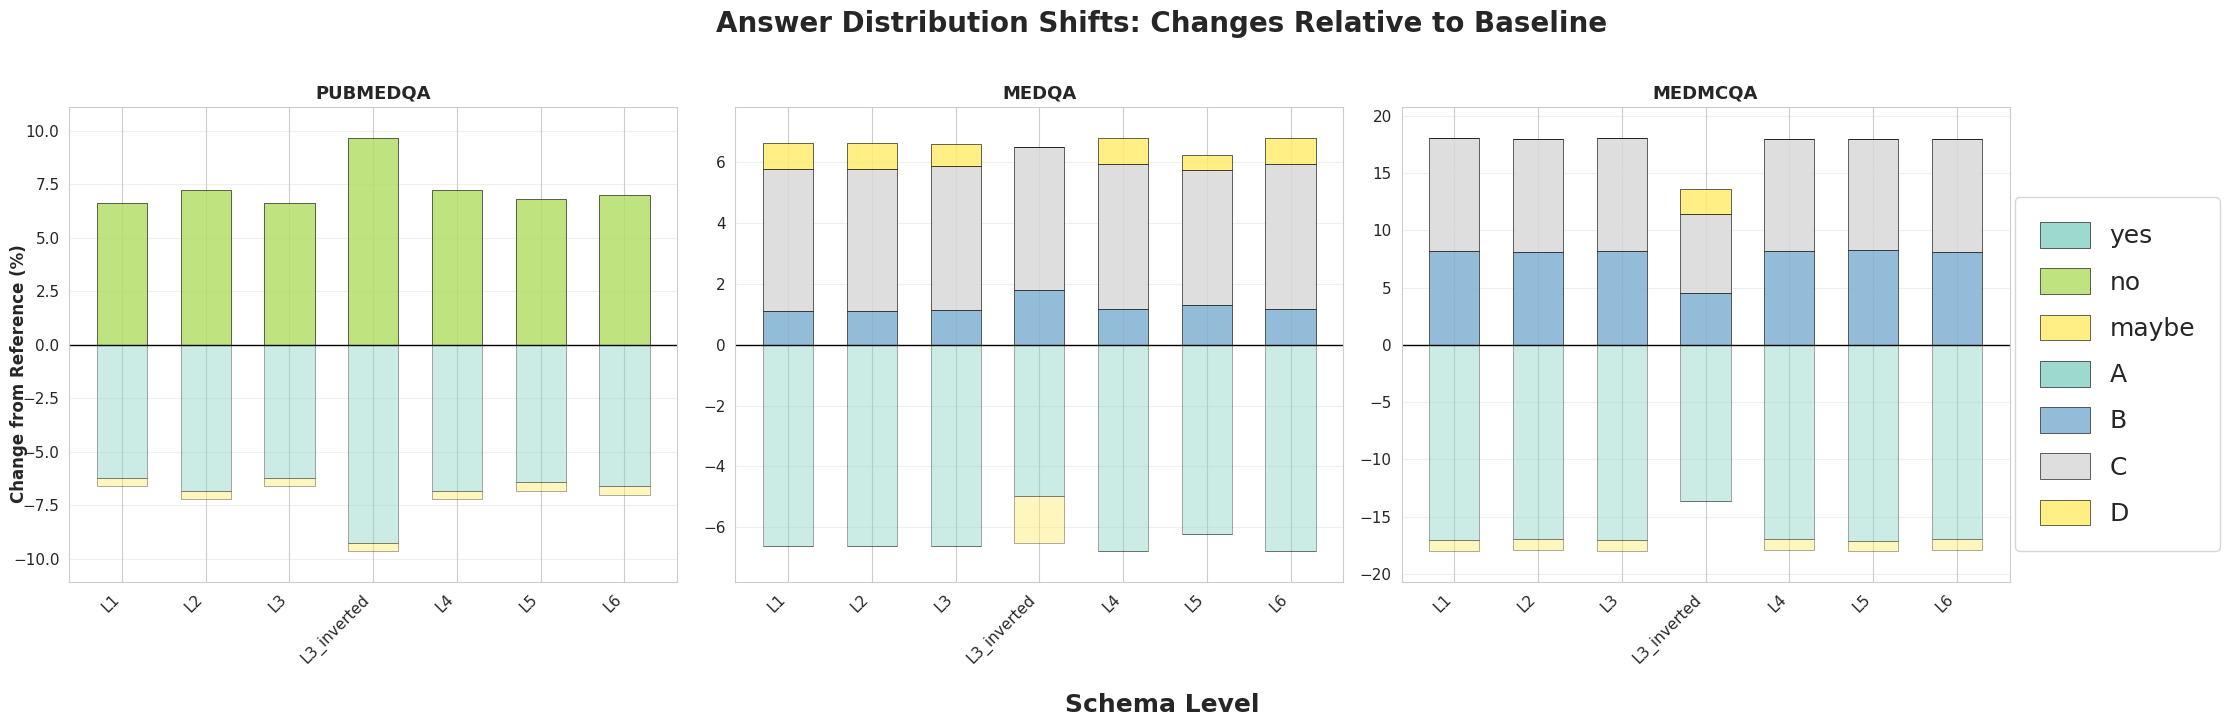

In [21]:
#  Answer distribution shift directions (stacked, +/- around 0) 
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# We'll build ONE legend: answer -> handle
legend_handles = {}

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]

    # Reference distribution
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    ref_item = next(
        (d for d in comprehensive_distribution_data
         if d['benchmark'] == benchmark and d['level'] == reference_level),
        None
    )
    if not ref_item:
        continue

    valid_answers = ref_item['valid_answers']
    ref_dist = ref_item['distribution']

    # Levels to plot (exclude reference)
    levels = [l for l in level_order if l in all_parsed[benchmark].keys() and l != reference_level]

    # Prepare shifts
    shifts_data = {ans: [] for ans in valid_answers}
    level_labels = []

    for level in levels:
        level_item = next(
            (d for d in comprehensive_distribution_data
             if d['benchmark'] == benchmark and d['level'] == level),
            None
        )
        if not level_item:
            continue

        level_labels.append(level)
        level_dist = level_item['distribution']

        for ans in valid_answers:
            shifts_data[ans].append(level_dist.get(ans, 0) - ref_dist.get(ans, 0))

    # X axis
    x = np.arange(len(level_labels))
    width = 0.6
    bottom_positive = np.zeros(len(level_labels))
    bottom_negative = np.zeros(len(level_labels))

    # Pastel categorical palette
    colors = plt.cm.Set3(np.linspace(0, 1, len(valid_answers)))

    for i, ans in enumerate(valid_answers):
        shifts = np.array(shifts_data[ans], dtype=float)
        pos = np.where(shifts > 0, shifts, 0.0)
        neg = np.where(shifts < 0, shifts, 0.0)

        # Positive bars (same color, higher alpha)
        if pos.sum() > 0:
            bars_pos = ax.bar(
                x, pos, width,
                bottom=bottom_positive,
                color=colors[i],
                alpha=0.85,
                edgecolor='black',
                linewidth=0.5
            )
            bottom_positive += pos

            # Register a SINGLE legend handle for this answer (use the positive handle)
            legend_handles.setdefault(ans, bars_pos[0])

        # Negative bars (same color, lower alpha)
        if neg.sum() < 0:
            ax.bar(
                x, neg, width,
                bottom=bottom_negative,
                color=colors[i],
                alpha=0.45,
                edgecolor='black',
                linewidth=0.5
            )
            bottom_negative += neg

            # If answer never appeared in positive, still register a handle
            if ans not in legend_handles:
                # create a tiny dummy bar handle (invisible) just for legend
                dummy = ax.bar([np.nan], [np.nan], color=colors[i], alpha=0.85,
                               edgecolor='black', linewidth=0.5)
                legend_handles[ans] = dummy[0]

    # Symmetric y-limits with padding (prevents clipping)
    max_pos = np.max(bottom_positive) if len(bottom_positive) > 0 else 0
    max_neg = np.min(bottom_negative) if len(bottom_negative) > 0 else 0
    ylim = max(abs(max_pos), abs(max_neg)) * 1.15 if max(abs(max_pos), abs(max_neg)) > 0 else 1
    ax.set_ylim(-ylim, ylim)

    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{benchmark.upper()}', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(level_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Shared axis labels
fig.supxlabel("Schema Level", fontsize=18, fontweight="bold")
fig.supylabel("Change from Reference (%)", fontsize=12, fontweight="bold")

# Bigger legend: larger font + larger color swatches
fig.legend(
    handles=list(legend_handles.values()),
    labels=list(legend_handles.keys()),
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),  
    fontsize=18,                 # increase legend text size
    frameon=True,
    handlelength=2.0,            
    handleheight=1.2,
    borderpad=1.0,
    labelspacing=0.8
)

plt.suptitle(
    'Answer Distribution Shifts: Changes Relative to Baseline',
    fontsize=20, fontweight='bold', y=1.02
)

# Leave room on the right for the legend (tune rect[2])
plt.tight_layout(rect=[0, 0, 0.86, 1])

plt.savefig(PLOTS_DIR / 'distribution_shift_directions.png', dpi=300, bbox_inches='tight')
plt.show()


## Cross-Benchmark Summary

This section provides a comprehensive summary of key findings across all benchmarks and evaluation points.


In [22]:
# Create summary tables
print("="*100)
print("CROSS-BENCHMARK SUMMARY")
print("="*100)

# 1. Accuracy Summary
print("\n1. ACCURACY UNDER STRUCTURED CONSTRAINTS")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'Accuracy (%)':<15} {'Change from Ref (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    # Get reference
    reference = 'baseline' if 'baseline' in bench_data['level'].values else 'L1'
    ref_acc = bench_data[bench_data['level'] == reference]['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == reference]) > 0 else None
    
    for _, row in bench_data.iterrows():
        level = row['level']
        acc = row['accuracy'] * 100
        change = (acc - ref_acc) if ref_acc is not None else 0
        change_str = f"{change:+.2f}" if ref_acc is not None else "N/A"
        print(f"{benchmark.upper():<15} {level:<10} {acc:<15.2f} {change_str:<20}")

# 2. Compliance Summary
print("\n2. OUTPUT VALIDITY AND SCHEMA COMPLIANCE")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'JSON Valid (%)':<18} {'Schema Compliant (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        json_valid = row['json_valid_rate'] * 100
        schema_compliant = row['schema_compliant_rate'] * 100
        print(f"{benchmark.upper():<15} {level:<10} {json_valid:<18.2f} {schema_compliant:<20.2f}")

# 3. Calibration Summary
print("\n3. CONFIDENCE AND CALIBRATION BEHAVIOR")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'ECE':<10} {'Correlation':<15} {'Mean Confidence':<18}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        ece = row['ece']
        corr = row['correlation']
        mean_conf = row['mean_confidence']
        print(f"{benchmark.upper():<15} {level:<10} {ece:<10.3f} {corr:<15.3f} {mean_conf:<18.3f}")


print("\n" + "="*100)


CROSS-BENCHMARK SUMMARY

1. ACCURACY UNDER STRUCTURED CONSTRAINTS
----------------------------------------------------------------------------------------------------
Benchmark       Level      Accuracy (%)    Change from Ref (%) 
----------------------------------------------------------------------------------------------------
PUBMEDQA        L1         77.20           +1.00               
PUBMEDQA        L2         77.40           +1.20               
PUBMEDQA        L3         77.20           +1.00               
PUBMEDQA        L3_inverted 76.40           +0.20               
PUBMEDQA        L4         77.40           +1.20               
PUBMEDQA        L5         77.40           +1.20               
PUBMEDQA        L6         77.60           +1.40               
PUBMEDQA        baseline   76.20           +0.00               
MEDQA           L1         62.14           +5.89               
MEDQA           L2         62.14           +5.89               
MEDQA           L3         